# Imports, Vars and Functions

In [1]:
%pip install lightgbm catboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 10.5 MB/s eta 0:00:00


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # one-liner charts, high-level
import plotly.graph_objects as go # full control chart

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool

import optuna

import typing

## Vars

In [3]:
TARGET = "Exited"
N_SPLITS = 5

categorical_columns = ["Geography", "Gender"]
numerial_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
]

drop_columns  = ["id", "CustomerId", "source"]
submission_columns = ["id", "Exited"]

## Functions

### Load Data

In [72]:
def load_data(option: str="local"):
  '''
  returns train_df, test_df, df

  '''
  if option == "local":
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')

  elif option == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    train_df = pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Bank Churn/train.csv')
    test_df = pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Bank Churn/test.csv')

  train_df['source'] = 'train'
  test_df['source'] = 'test'
  df = pd.concat([train_df, test_df], ignore_index=True)

  return train_df, test_df, df

### Data splitter

In [97]:
def data_spliter(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    '''
    return: X_train, y_train, submission_df

    '''
    train = df[df['source'] == 'train'].drop(columns=drop_columns)
    submission_df = df[df['source'] == 'test'].drop(columns=['source', TARGET])

    X_train = train.drop(columns=[TARGET])
    y_train = train[TARGET]

    return X_train, y_train, submission_df

In [90]:
train_df, test_df, df = load_data(option="colab")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# EDA

In [9]:
len(df)

25000

-   **Customer** ID: Уникальный идентификатор каждого клиента.
-   **Surname**: Фамилия клиента.
-   **Credit Score**: Числовое значение, представляющее кредитный рейтинг клиента.
-   **Geography**: Страна проживания клиента (Франция, Испания или Германия).
-   **Gender**: Пол клиента (Мужской или Женский).
-   **Age**: Возраст клиента.
-   **Tenure**: Количество лет, которое клиент обслуживается в банке.
-   **Balance**: Баланс на счёте клиента.
-   **NumOfProducts**: Количество банковских продуктов, которыми пользуется клиент (например, сберегательный счёт, кредитная карта).
-   **HasCrCard**: Наличие кредитной карты у клиента (1 = да, 0 = нет).
-   **IsActiveMember**: Является ли клиент активным членом банка (1 = да, 0 = нет).
-   **EstimatedSalary**: Предполагаемая заработная плата клиента.
-   **Exited**: Ушёл ли клиент (1 = да, 0 = нет).


In [ ]:
df.info()

In [ ]:
df.describe().T

In [ ]:
df.isna().sum()

In [ ]:
df.head()

## Pairplot

In [10]:
fig = sns.pairplot(
    data=train_df[numerial_columns + [TARGET]],
    hue=TARGET,
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 15, "edgecolor": None},
    diag_kws={"fill": True, "alpha": 0.6},
    palette={0: "#2196F3", 1: "#FF5722"},
    # corner=True,
)
fig.figure.suptitle("Pairplot of Numerical Features by Churn Status", y=1.02, fontsize=16, fontweight="bold")

Text(0.5, 1.02, 'Pairplot of Numerical Features by Churn Status')

Error in callback <function _draw_all_if_interactive at 0x7bf239b6b6a0> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7bf239b68ae0> (for post_execute):


KeyboardInterrupt: 

## Correlations

<Axes: >

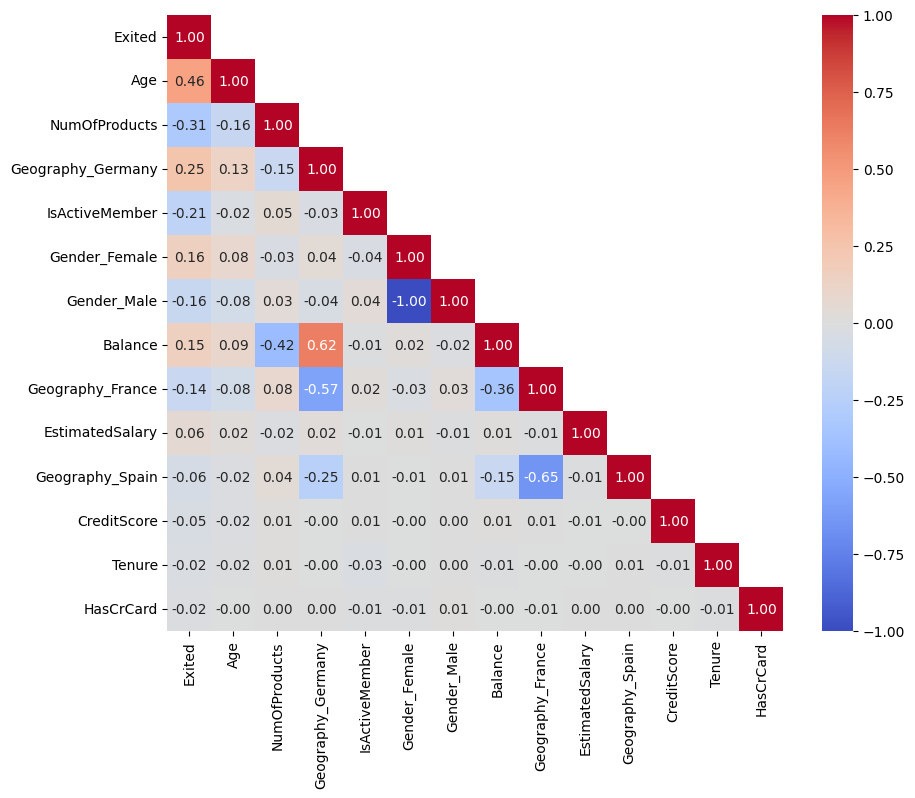

In [19]:
corr_df = pd.get_dummies(
        data=df.drop(columns=drop_columns + ["source"] + ["Surname"]),
        columns=["Gender", "Geography"],
    ).corr()
sorted_columns = corr_df[TARGET].abs().sort_values(ascending=False).index.tolist()
corr_df = corr_df.loc[sorted_columns, sorted_columns]
corr_mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)

plt.figure(figsize=(10,8))
sns.heatmap(
    data=corr_df,
    mask=corr_mask,
    annot=True,
    fmt='.2f',
    cmap="coolwarm",
    square=True,
    center=0
)

In [40]:
corr_df[corr_mask] = np.nan
px.imshow(
    corr_df,
    text_auto= ".2f",
    aspect = True,
    color_continuous_scale="RdBu_r"
).update_traces(hoverongaps=False)

## Surnames

In [ ]:
display(df['Surname'].value_counts().reset_index())

In [ ]:
df[df['Surname'].str.endswith('ov') | df['Surname'].str.endswith('ova') | df['Surname'].str.endswith('ev') | df['Surname'].str.endswith('eva')]

In [ ]:
df[df['Surname'].str.contains("?", regex=False)]

In [ ]:
display(df[df['Surname'].str.contains("'", regex=False)])

## Balance

<Axes: xlabel='Balance', ylabel='Count'>

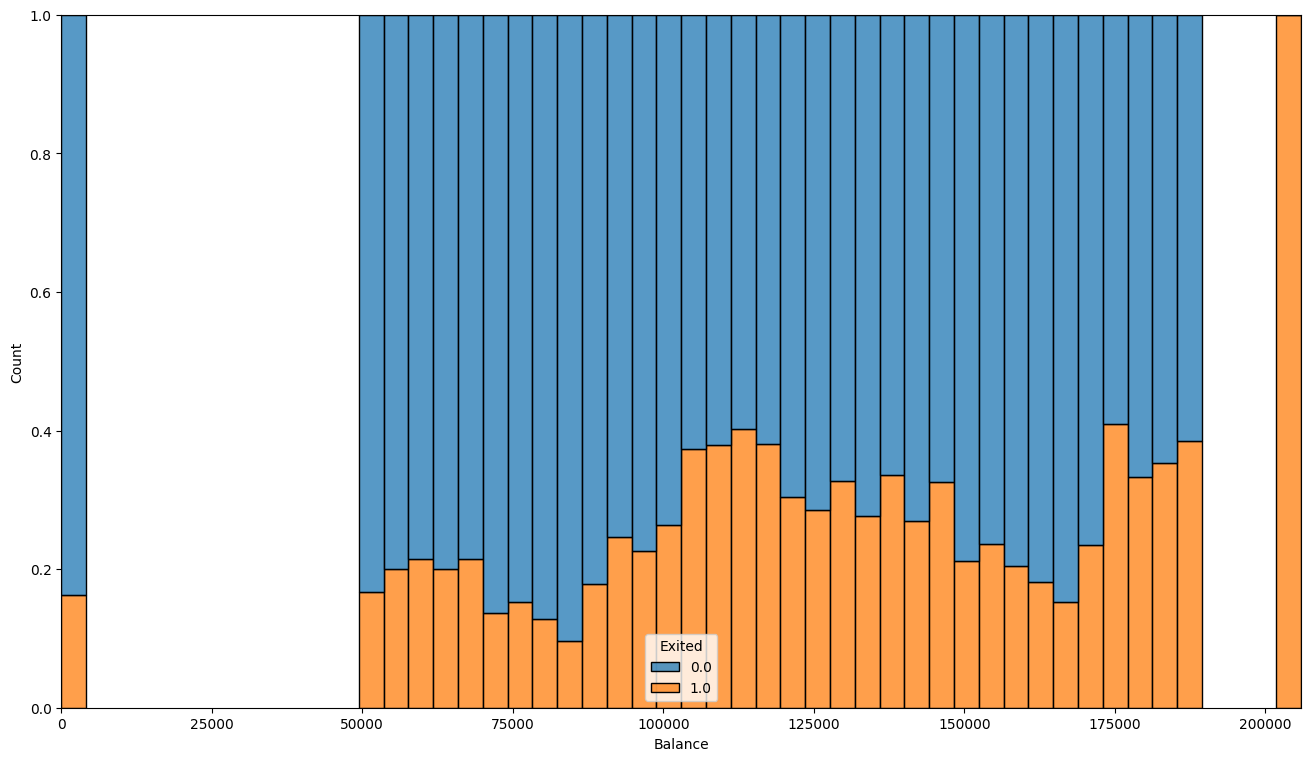

In [12]:
plt.figure(figsize=(16,9))
sns.histplot(
    data=train_df,
    x="Balance",
    hue='Exited',
    bins=50,
    multiple='fill',
)

In [13]:
df['Balance'].drop_duplicates().sort_values(ascending=False).head()

,Balance
5754,205962.00
4965,203715.15
12478,187841.99
16912,187534.79
4517,187530.66


In [14]:
df[df['Balance'] > 200000]

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,source
4965,4965,15798964.0,O'Donnell,613.0,Spain,Male,51.0,8.0,203715.15,1.0,1.0,1.0,157549.90,1.0,train
5754,5754,15673074.0,Chidiebele,726.0,France,Female,52.0,9.0,205962.00,1.0,1.0,0.0,75888.65,1.0,train


## Salary

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=train_df,
    x="EstimatedSalary",
    hue='Exited',
    bins=50,
    multiple='fill',
)

## Age

In [15]:
px.histogram(
    data_frame=df,
    x = 'Age',
    # y='Balance',
    color='Exited',
    barmode='overlay',
    opacity=0.6,
    marginal="box",
    # histfunc="avg"
    # nbins=70,
    # text_auto=True
    # range_x=[17,74]
).update_layout(bargap=0.1)

In [16]:
df['Age'].value_counts().reset_index().sort_values(by='Age').head()

,Age,count
52,18.0,7
48,19.0,15
44,20.0,37
41,21.0,66
36,22.0,111


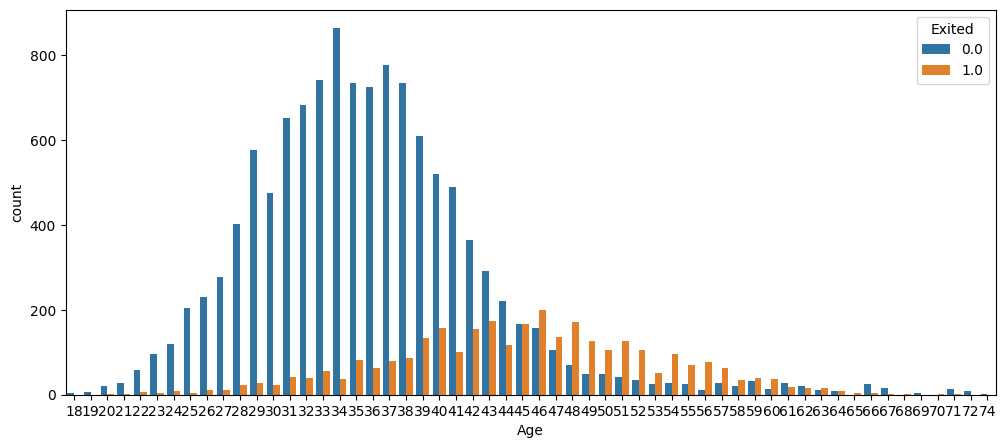

In [17]:
plt.figure(figsize=(12,5))
ax = sns.countplot(
    data=train_df,
    x=df['Age'].astype(int),
    hue='Exited',
)

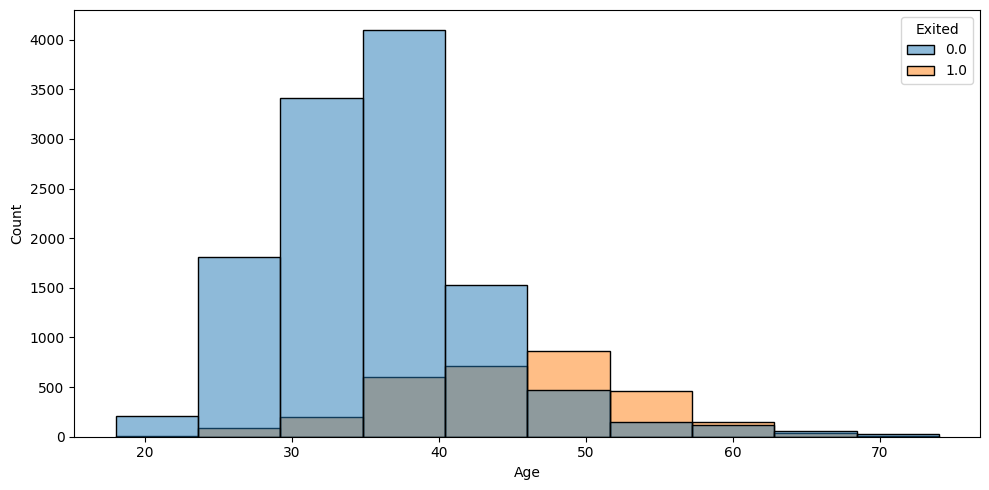

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=train_df,
    x="Age",
    hue='Exited',
    bins=10,
    # multiple='fill',
)
# plt.xticks(np.arange(18,75))
plt.tight_layout()

## Credit Score

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=train_df,
    x="CreditScore",
    hue='Exited',
    bins=5,
    multiple='fill',
)
# plt.xticks(np.arange(18,75))
plt.tight_layout()

# Feature Engineering

In [59]:
train_df, test_df, df = load_data(option='colab')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [91]:
def feature_engineering(df):
  original_columns = df.columns.tolist()
  print("Engineering features...")

  # 1. Interaction & Ratio Features
  df['Balance_to_Salary_Ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
  df['Age_to_Tenure_Ratio'] = df['Tenure'] / (df['Age'] + 1)
  df['Products_per_Tenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)

  # 2. Financial Status & Behavior Indicators
  df['Is_Zero_Balance'] = (df['Balance'] == 0).astype(int)

  # # CreditScore Binning
  # score_bins = [0, 579, 669, 739, 799, 850]
  # score_labels = ['Very_Poor', 'Fair', 'Good', 'Very_Good', 'Exceptional']
  # df['CreditScore_Segment'] = pd.cut(df['CreditScore'], bins=score_bins, labels=score_labels).astype(str)

  # # Age Binning (targeting the peak churn between 45 and 60)
  # age_bins = [0, 30, 45, 60, 100]
  # age_labels = ['Under_30', '30_to_45', '45_to_60', 'Over_60']
  # df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels).astype(str)

  # 3. Engagement Score
  df['Customer_Activity_Index'] = df['HasCrCard'] + df['IsActiveMember'] + (df['NumOfProducts'] > 1).astype(int)

  # 4. Surname & Demographic Patterns
  # Surname length and special character rules
  df['Surname_Has_Question'] = df['Surname'].str.contains('?', regex=False).astype(int)

  # Endings often representing specific ethnicities/families in synthetic datasets
  df['Surname_Ends_With_Slavic'] = df['Surname'].str.endswith(('ov', 'ova', 'ev', 'eva')).astype(int)

  # Convert gended to numbers
  df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

  engineered_features = [k for k in df.columns.tolist() if k not in original_columns]

  print(f"\nAdded {len(engineered_features)} features")
  print(f"Features added:")
  for idx, f in enumerate(engineered_features):
    print(f"{idx + 1}: {f}")
  return df

In [92]:
df = feature_engineering(df)

Engineering features...

Added 7 features
Features added:
1: Balance_to_Salary_Ratio
2: Age_to_Tenure_Ratio
3: Products_per_Tenure
4: Is_Zero_Balance
5: Customer_Activity_Index
6: Surname_Has_Question
7: Surname_Ends_With_Slavic


In [75]:
with pd.option_context('display.max_columns', None):
    display(df.head())

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,source,Balance_to_Salary_Ratio,Age_to_Tenure_Ratio,Products_per_Tenure,Is_Zero_Balance,Customer_Activity_Index,Surname_Has_Question,Surname_Ends_With_Slavic
0,0,15653521.0,Nkemakonam,667.0,Germany,1,33.0,3.0,131769.04,1.0,1.0,1.0,162719.69,0.0,train,0.809787,0.088235,0.250000,0,2.0,0,0
1,1,15699005.0,Chiekwugo,614.0,France,0,31.0,2.0,110615.47,1.0,1.0,1.0,181879.56,0.0,train,0.608176,0.062500,0.333333,0,2.0,0,0
2,2,15656912.0,Chiang,683.0,Germany,0,24.0,6.0,115074.02,2.0,1.0,0.0,109688.82,0.0,train,1.049086,0.240000,0.285714,0,2.0,0,0
3,3,15700772.0,Ch'ang,678.0,France,0,38.0,9.0,0.00,1.0,1.0,0.0,122823.84,1.0,train,0.000000,0.230769,0.100000,1,1.0,0,0
4,4,15583850.0,Chiang,588.0,Spain,0,39.0,3.0,0.00,2.0,1.0,1.0,136910.18,0.0,train,0.000000,0.075000,0.500000,1,3.0,0,0


# Modelling

In [93]:
X, y, submission_df = data_spliter(df)

In [45]:
cv = StratifiedKFold(
    n_splits = N_SPLITS,
    shuffle = True,
    random_state=42
)

## LightGBM

In [76]:
lgb_params = {
    "n_estimators":10000,
    "learning_rate": 0.05,
    "num_leaves": 40,
    "min_child_samples": 30,
    "colsample_bytree": 0.8,
    "subsample": 0.8,
    "subsample_freq": 1
}

In [77]:
preprocess = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), ['Geography'])]
)
lgb_pipeline = Pipeline(
    [
        ("preprocessor", preprocess),
        ("lgb", LGBMClassifier(**lgb_params))
    ]
)

In [96]:
X

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,source
0,0,15653521.0,Nkemakonam,667.0,Germany,Male,33.0,3.0,131769.04,1.0,1.0,1.0,162719.69,train
1,1,15699005.0,Chiekwugo,614.0,France,Female,31.0,2.0,110615.47,1.0,1.0,1.0,181879.56,train
2,2,15656912.0,Chiang,683.0,Germany,Female,24.0,6.0,115074.02,2.0,1.0,0.0,109688.82,train
3,3,15700772.0,Ch'ang,678.0,France,Female,38.0,9.0,0.00,1.0,1.0,0.0,122823.84,train
4,4,15583850.0,Chiang,588.0,Spain,Female,39.0,3.0,0.00,2.0,1.0,1.0,136910.18,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15793331.0,Kao,537.0,Spain,Female,43.0,8.0,0.00,2.0,1.0,1.0,57762.00,train
14996,14996,15651336.0,Kambinachi,669.0,Spain,Female,34.0,4.0,0.00,2.0,0.0,0.0,138775.86,train
14997,14997,15764072.0,Chiu,537.0,France,Male,39.0,7.0,0.00,2.0,0.0,0.0,141210.50,train
14998,14998,15792868.0,Ts'ai,651.0,France,Male,31.0,9.0,0.00,2.0,1.0,1.0,177655.68,train


In [94]:
[col for col in submission_df.columns if col not in X.columns]

['Balance_to_Salary_Ratio',
 'Age_to_Tenure_Ratio',
 'Products_per_Tenure',
 'Is_Zero_Balance',
 'Customer_Activity_Index',
 'Surname_Has_Question',
 'Surname_Ends_With_Slavic']

In [84]:
submission_df.shape

(10000, 20)

In [ ]:
oof = np.zeros(len(X))
subsmission_results = np.zeros(len(submission_df))


In [81]:
for fold, (tr_idx, val_idx) in enumerate(cv.split(X,y)):
  X_train, y_train = X.iloc[tr_idx], y.iloc[val_idx]
  X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

  lgb_pipleine.fit(X_train, y_train)


[    0     1     2 ... 14996 14997 14999]
[    5     9    11 ... 14981 14990 14998]
[    0     1     2 ... 14997 14998 14999]
[    4     6    12 ... 14987 14988 14992]
[    2     4     5 ... 14995 14998 14999]
[    0     1     3 ... 14994 14996 14997]
[    0     1     3 ... 14996 14997 14998]
[    2     7    10 ... 14982 14989 14999]
[    0     1     2 ... 14997 14998 14999]
[    8    13    15 ... 14984 14985 14995]
